# Конструирование алгоритмов `lscp`

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

from genesis.core import BestPointsBase, MetricBase, StateBase, StopCaseBase, LSCPBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.mclp import BestNodesKoptG
from genesis.tools import list_dict_concat
from genesis.utils import timing
from genesis.swiss_knife import CMAP_GrGldRd


In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [3]:
def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=CMAP_GrGldRd, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

def iter_func(**kwds):
    'Функция вывода хода расчета'
    print(kwds)

# Разработка

In [16]:
from genesis.best_points import NodeMetric
from genesis.core import MetricBase, StateBase
from genesis.point_selectors import GenesisNodeSelector
from genesis.tools import get_dict_key


h = {}

class BestNodesGenesis(LSCPBase):
    '''
    Расчет количества и оптимального размещения узлов для достижения целевой метрики.

    Выполняется методом `Генезис`.
    '''
    def __init__(self,
                 mclp_function: BestPointsBase,
                 stop_case_function: StopCaseBase,
                #  appr_val: float = 0.95,
                 **kwargs):
        # self.node_metric_func = NodeMetric(state_function,
        #                                    metric_function,
        #                                    appr_val,
        #                                    err_val=None,
        #                                    **kwargs)
        self.mclp_function = mclp_function
        self.stop_case_function = stop_case_function

        super().__init__(mclp_function, stop_case_function, **kwargs)

    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        Запуск работы алгоритма

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''

        best_dynamic_nodes = dynamic_nodes

        # Опускаем флаг прекращения расчетов
        stop_flag = False

        # Итерации
        iteration = 0
        while not stop_flag:
            # 1. Расчет оптимального размещения подразделений
            best_dynamic_nodes, best_metric = self.mclp_function(env=env,
                                            dynamic_nodes=best_dynamic_nodes,
                                            static_nodes=static_nodes,
                                            area=area,
                                            **kwargs)

            # 2. Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function(value=best_metric,
                            iteration=iteration,
                            best_metric=best_metric,
                            dynamic_nodes=best_dynamic_nodes,
                            static_nodes=static_nodes):
                return best_dynamic_nodes, best_metric

            # ============================================================================================
            # 3. Если нет - создаем новое подразделение
            # 3.1. Получение суммарного списка (или словаря) узлов для расчета состояния и метрик
            start_nodes = list_dict_concat(dynamic_nodes, static_nodes)

            new_node = GenesisNodeSelector(FirstArrivalUnitState(), ArrivalTime())(env, start_nodes)

            # Добавление нового узла в словарь динамических узлов:
            best_dynamic_nodes[new_node] = str(iteration)
            print(best_dynamic_nodes)

            iteration += 1

        return best_dynamic_nodes, best_metric
            
            


class ItersStopCase(StopCaseBase):
    '''
    Критерий остановки по условию, что на протяжении нескольких итераций
    значения равны, т.е. не изменяются
    '''
    def __init__(self, max_iter_count=2):
        self.max_iter_count = max_iter_count

    def __call__(self, **kwargs):
        print(kwargs)
        iters_count = kwargs['iteration']
        
        return iters_count>=self.max_iter_count



# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)


nodes = list(G.nodes())
existed_units = {nodes[100]:'A', 
                nodes[2000]:'B', 
                }
new_units = {nodes[3000]:'c',
             nodes[4000]:'d'}



BNHC = BestNodeHillClimbing(state_function = FirstArrivalUnitState(),
                            metric_function = ArrivalTime())

BNG = BestNodesKoptG(state_function = FirstArrivalUnitState(),
                    metric_function = ArrivalTime(),
                    best_point_function = BNHC,
                    iterations = 5,
                    )

stop_case = ItersStopCase(max_iter_count = 2)


# genesis = BestNodesGenesis(FirstArrivalUnitState(), ArrivalTime(), BNG, stop_case)
genesis = BestNodesGenesis(mclp_function = BNG,
                           stop_case_function = stop_case)

best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = new_units,
                                static_nodes = existed_units)

best_dynamic_nodes, best_metric

{'value': 6.984608999416008, 'iteration': 0, 'best_metric': 6.984608999416008, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{4116059950: 'c', 5116722296: 'd', 2042076753: '0'}
{'value': 4.667819914049523, 'iteration': 1, 'best_metric': 4.667819914049523, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd', 2034401761: '0'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{4116059950: 'c', 5116722296: 'd', 2034401761: '0', 2042076753: '1'}
{'value': 4.526682571130086, 'iteration': 2, 'best_metric': 4.526682571130086, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd', 2034401777: '0', 2054469107: '1'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


({4116059950: 'c', 5116722296: 'd', 2034401777: '0', 2054469107: '1'},
 4.526682571130086)

In [17]:
best_dynamic_nodes

{4116059950: 'c', 5116722296: 'd', 2034401777: '0', 2054469107: '1'}

<Axes: >

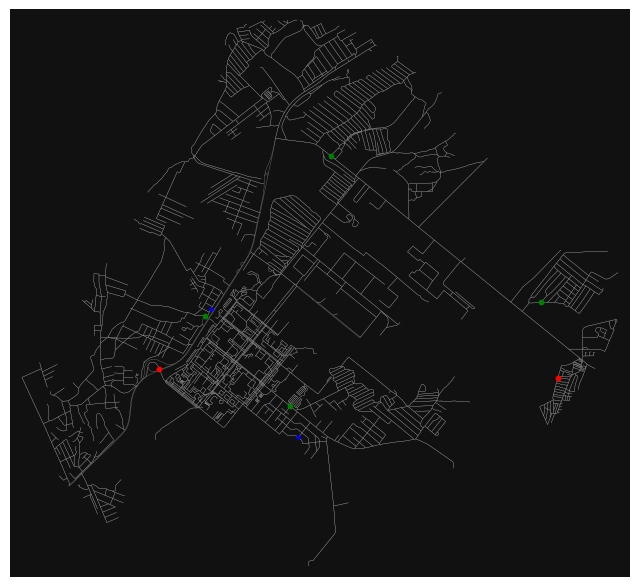

In [19]:
g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)

# start_units = {**existed_units, **new_units}

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[best_dynamic_nodes.keys()].plot(ax=ax, c='g', markersize=10)
g_nodes_gdf.loc[existed_units.keys()].plot(ax=ax, c='r', markersize=10)
g_nodes_gdf.loc[new_units.keys()].plot(ax=ax, c='b', markersize=5)